In [1]:
# CUDA 12.1
!pip -q install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 59.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 66.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 56.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 89.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━

In [40]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.5.1+cu121
Torchvision version: 0.20.1+cu121
CUDA is available: False


In [3]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/Pintu587/sam2'

!mkdir -p images
!wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/truck.jpg
!wget -P images https://raw.githubusercontent.com/facebookresearch/sam2/main/notebooks/images/groceries.jpg

!mkdir -p ../checkpoints/
!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

PyTorch version: 2.5.1+cu121
Torchvision version: 0.20.1+cu121
CUDA is available: False
  Cloning https://github.com/Pintu587/sam2 to /tmp/pip-req-build-0gny9vyy
  Running command git clone --filter=blob:none --quiet https://github.com/Pintu587/sam2 /tmp/pip-req-build-0gny9vyy
  Resolved https://github.com/Pintu587/sam2 to commit 2b7bcf7a4ea6206cef7a55d1c6035099c871d338
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
  Created wheel for SAM-2: filename=sam_2-1.0-cp311-cp311-linux_x86_64.whl size=183621 sh

In [4]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cpu


In [6]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [7]:
image = Image.open('images/truck.jpg')
image = np.array(image.convert("RGB"))

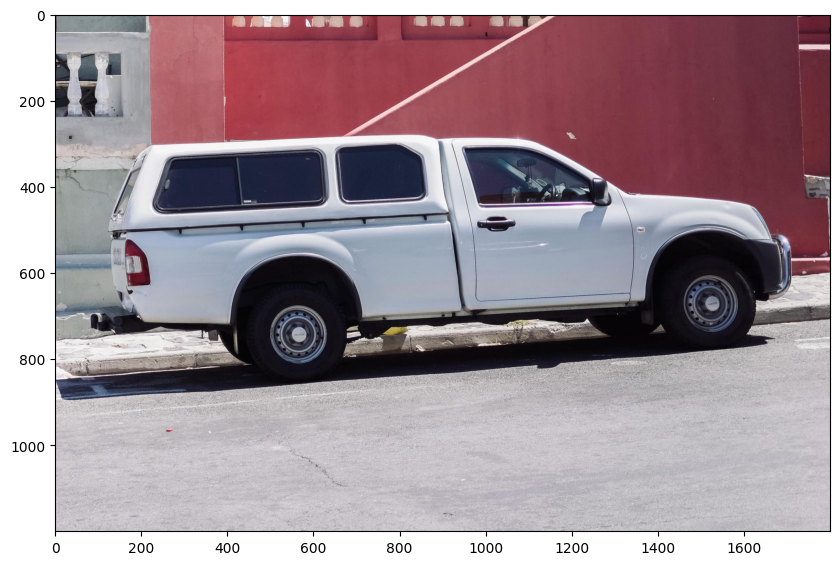

In [8]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('on')
plt.show()

In [9]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint,device = "cpu")

predictor = SAM2ImagePredictor(sam2_model)

In [10]:
predictor.set_image(image)

In [11]:
input_point = np.array([[500, 375]])
input_label = np.array([1])

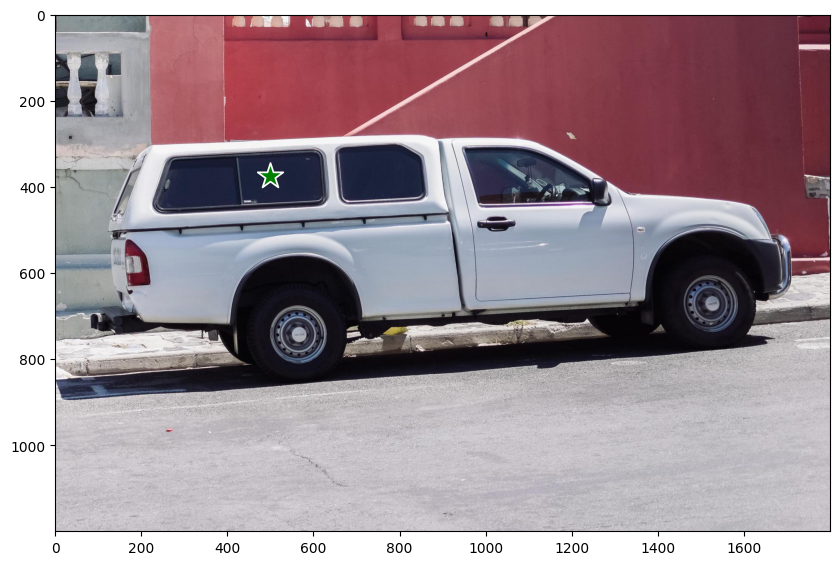

In [12]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

In [13]:
print(predictor._features["image_embed"].shape, predictor._features["image_embed"][-1].shape)

torch.Size([1, 256, 64, 64]) torch.Size([256, 64, 64])


In [14]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)
sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]

In [15]:
masks.shape  # (number_of_masks) x H x W

(3, 1200, 1800)

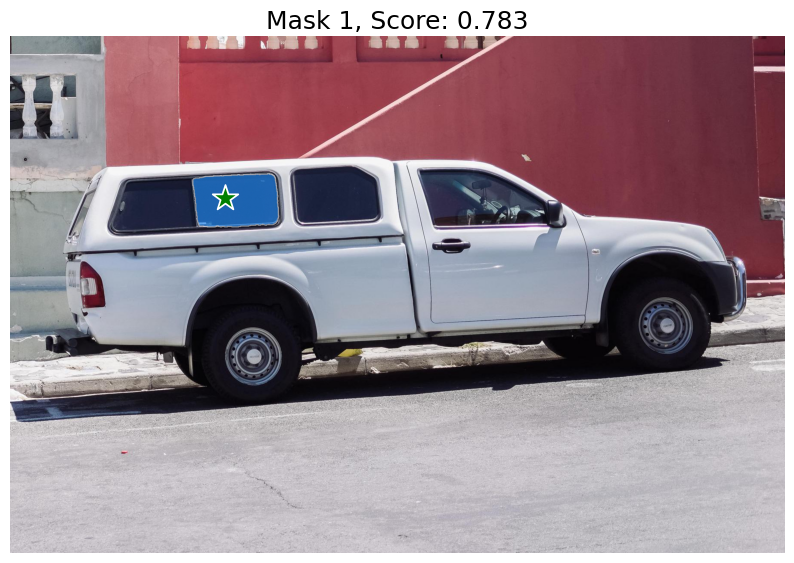

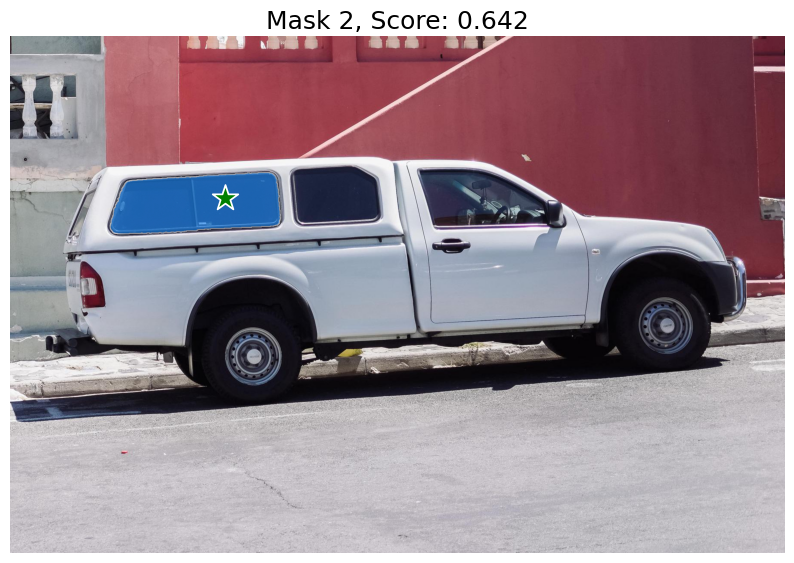

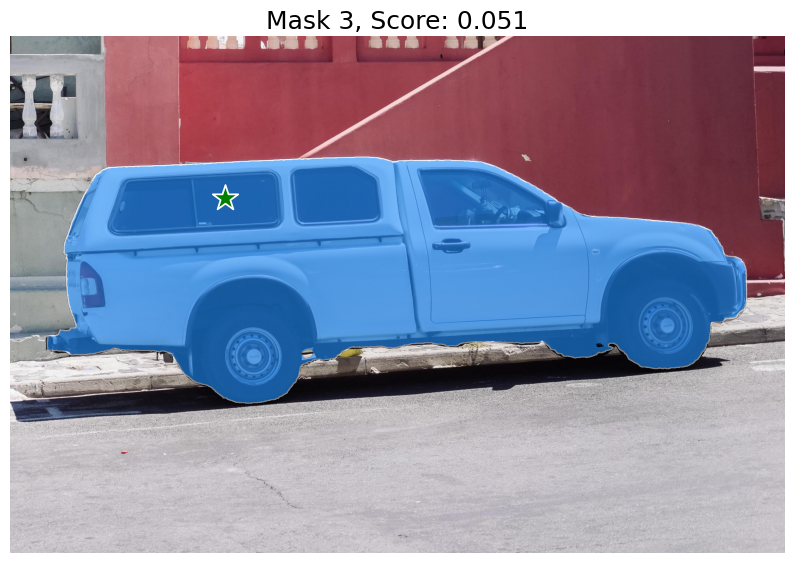

In [16]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

In [17]:
import cv2
import numpy as np
from PIL import Image
from typing import Any, Dict, List


def load_img_to_array(img_p):
    img = Image.open(img_p)
    if img.mode == "RGBA":
        img = img.convert("RGB")
    return np.array(img)

def save_array_to_img(img_arr, img_p):
    Image.fromarray(img_arr.astype(np.uint8)).save(img_p)


def dilate_mask(mask, dilate_factor=15):
    mask = mask.astype(np.uint8)
    mask = cv2.dilate(
        mask,
        np.ones((dilate_factor, dilate_factor), np.uint8),
        iterations=1
    )
    return mask

def erode_mask(mask, dilate_factor=15):
    mask = mask.astype(np.uint8)
    mask = cv2.erode(
        mask,
        np.ones((dilate_factor, dilate_factor), np.uint8),
        iterations=1
    )
    return mask

def show_mask(ax, mask: np.ndarray, random_color=False):
    mask = mask.astype(np.uint8)
    if np.max(mask) == 255:
        mask = mask / 255
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_img = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_img)


def show_points(ax, coords: List[List[float]], labels: List[int], size=375):
    coords = np.array(coords)
    labels = np.array(labels)
    color_table = {0: 'red', 1: 'green'}
    for label_value, color in color_table.items():
        points = coords[labels == label_value]
        ax.scatter(points[:, 0], points[:, 1], color=color, marker='*',
                   s=size, edgecolor='white', linewidth=1.25)

def get_clicked_point(img_path):
    img = cv2.imread(img_path)
    cv2.namedWindow("image")
    cv2.imshow("image", img)

    last_point = []
    keep_looping = True

    def mouse_callback(event, x, y, flags, param):
        nonlocal last_point, keep_looping, img

        if event == cv2.EVENT_LBUTTONDOWN:
            if last_point:
                cv2.circle(img, tuple(last_point), 5, (0, 0, 0), -1)
            last_point = [x, y]
            cv2.circle(img, tuple(last_point), 5, (0, 0, 255), -1)
            cv2.imshow("image", img)
        elif event == cv2.EVENT_RBUTTONDOWN:
            keep_looping = False

    cv2.setMouseCallback("image", mouse_callback)

    while keep_looping:
        cv2.waitKey(1)

    cv2.destroyAllWindows()

    return last_point

In [20]:
import sys
import argparse
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from typing import Any, Dict, List
import torch
from hydra import initialize, compose
from omegaconf import OmegaConf

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

def predict_masks_with_sam(
        img: np.ndarray,
        point_coords: List[List[float]],
        point_labels: List[int],
        device="cpu",
        refinement_mode=None
):
    point_coords = np.array(point_coords)
    point_labels = np.array(point_labels)

    sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
    model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

    sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
    predictor = SAM2ImagePredictor(sam2_model)

    predictor.set_image(img)

    '''
    Predict with SAM2ImagePredictor.predict. The model returns masks,
    quality predictions for those masks, and low resolution mask logits
    that can be passed to the next iteration of prediction.
    '''

    masks, scores, logits = predictor.predict(
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=True,
    )

    '''
    With multimask_output=True (the default setting), SAM 2 outputs 3 masks,
    where scores gives the model's own estimation of the quality of these masks.
    This setting is intended for ambiguous input prompts, and helps the model
    disambiguate different objects consistent with the prompt
    '''

    sorted_ind = np.argsort(scores)[::-1]
    masks = masks[sorted_ind]
    scores = scores[sorted_ind]
    logits = logits[sorted_ind]

    return masks, scores, logits

In [36]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt

# Define the latest_coords and point_labels as flattened tensors
latest_coords = torch.tensor([[250, 250]], dtype=torch.float32)  # Shape: (1, 2)
point_labels = torch.tensor([1], dtype=torch.int64)  # Shape: (1,)

input_img = '/content/baseball.jpg'
dilate_kernel_size = 15
output_dir = '/content/output'
img_array = load_img_to_array(input_img)

# Set device (can be "cpu" or "cuda")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Predict masks using SAM with corrected inputs
masks, _, _ = predict_masks_with_sam(
    img_array,
    latest_coords.unsqueeze(0),  # Shape: (1, 1, 2)
    point_labels.unsqueeze(0),   # Shape: (1, 1)
    device=device,
)
masks = masks.astype(np.uint8) * 255

# Dilate mask if required
if dilate_kernel_size is not None:
    masks = [dilate_mask(mask, dilate_kernel_size) for mask in masks]

# Prepare output directories
img_stem = Path(input_img).stem
out_dir = Path(output_dir) / img_stem
out_dir.mkdir(parents=True, exist_ok=True)

# Save visualizations and masks
for idx, mask in enumerate(masks):
    mask_p = out_dir / f"mask_{idx}.png"
    img_points_p = out_dir / f"with_points.png"
    img_mask_p = out_dir / f"with_{mask_p.name}"

    save_array_to_img(mask, mask_p)

    dpi = plt.rcParams['figure.dpi']
    height, width = img_array.shape[:2]
    plt.figure(figsize=(width / dpi / 0.77, height / dpi / 0.77))
    plt.imshow(img_array)
    plt.axis('off')

    # Flatten coords and labels for plotting
    show_points(plt.gca(), latest_coords.numpy(), point_labels.numpy(),
                size=(width * 0.04)**2)
    plt.savefig(img_points_p, bbox_inches='tight', pad_inches=0)

    show_mask(plt.gca(), mask, random_color=False)
    plt.savefig(img_mask_p, bbox_inches='tight', pad_inches=0)
    plt.close()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show_image(img_path):
    image = Image.open(img_path)
    image = np.array(image.convert("RGB"))
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('on')
    plt.show()

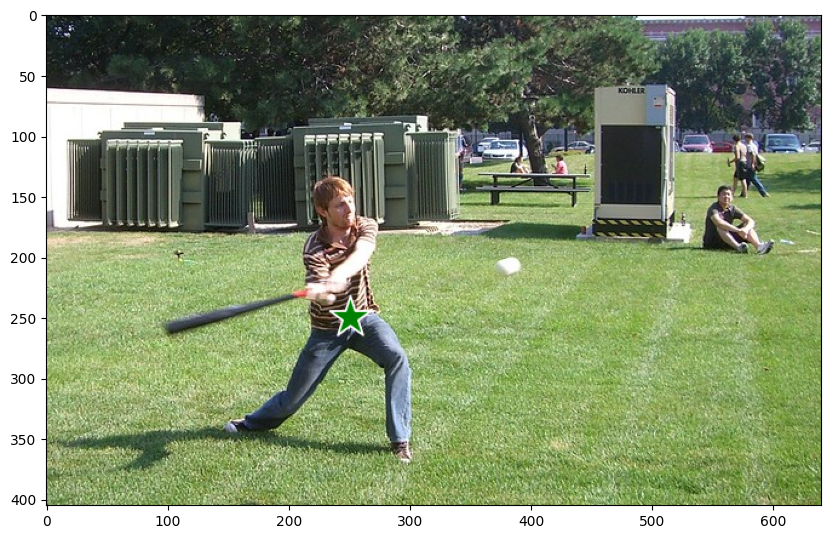

In [38]:
show_image('/content/output/baseball/with_points.png')

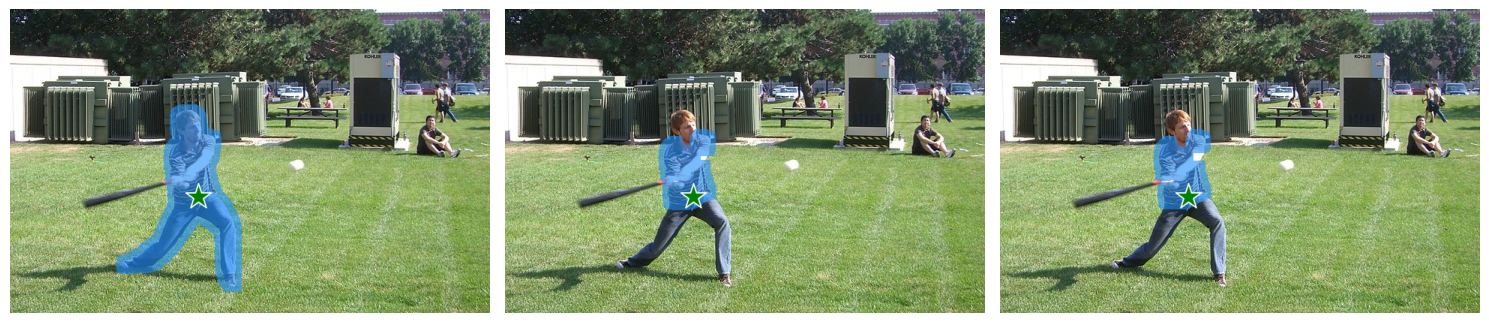

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show_image_grid(img_paths):
    # Create a figure with a grid of 1 row and 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize for appropriate scaling

    for i, img_path in enumerate(img_paths):
        image = Image.open(img_path)
        image = np.array(image.convert("RGB"))

        # Display each image in the grid (1x3)
        axes[i].imshow(image)
        axes[i].axis('off')  # Hide axes for cleaner display

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()

# Example usage:
image_paths = ["/content/output/baseball/with_mask_0.png", "/content/output/baseball/with_mask_1.png", "/content/output/baseball/with_mask_2.png"]
show_image_grid(image_paths)
